In [ ]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.neural_network import MLPClassifier

from tensorflow.keras.layers import Input, Dense, MaxPooling2D, Conv2D, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers, datasets
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/Work 2025-2026/ADSA')
import adsa_utils as ad


## The Iris Dataset

In [ ]:
iris = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Work 2025-2026/ADSA/iris.csv', sep=';')
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sepallength  150 non-null    float64
 1   sepalwidth   150 non-null    float64
 2   petallength  150 non-null    float64
 3   petalwidth   150 non-null    float64
 4   iris         150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
# separate the class label from regular attributes
y = iris[['iris']]
X = iris[iris.columns.difference(['iris'])]
# split the dataset into 2 portions:
# one for training and validation, one for the final testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=43
)

## Baseline Classification Models from Previous weeks

Mean accuracy: 93.33% +/-2.04%
Mean precision: 93.70% +/-2.12%
Mean recall: 93.61% +/-2.02%
Mean F1-score is 93.56% +/-1.96%
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        37
Iris-versicolor       0.90      0.90      0.90        42
 Iris-virginica       0.90      0.90      0.90        41

       accuracy                           0.93       120
      macro avg       0.94      0.94      0.94       120
   weighted avg       0.93      0.93      0.93       120



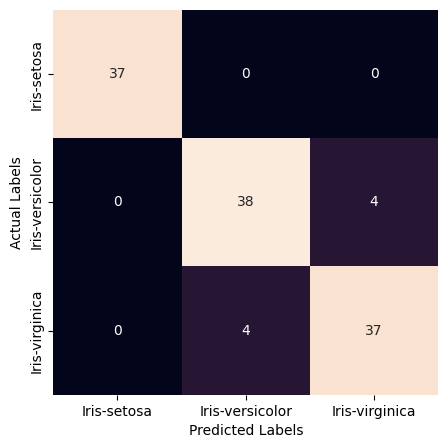

In [ ]:
dt = DecisionTreeClassifier(random_state=43)
ad.custom_crossvalidation(X_train, y_train, dt)

Mean accuracy: 94.17% +/-5.00%
Mean precision: 95.27% +/-3.93%
Mean recall: 94.72% +/-4.49%
Mean F1-score is 94.47% +/-4.76%
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        37
Iris-versicolor       0.91      0.93      0.92        42
 Iris-virginica       0.93      0.90      0.91        41

       accuracy                           0.94       120
      macro avg       0.94      0.94      0.94       120
   weighted avg       0.94      0.94      0.94       120



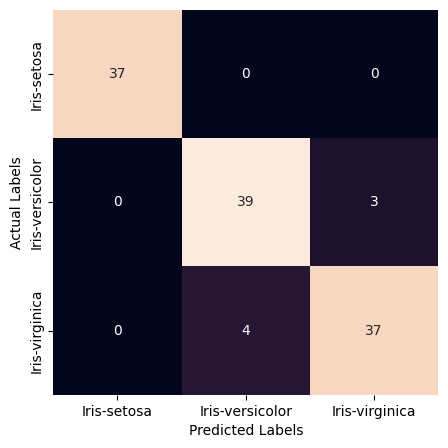

In [ ]:
knn = KNeighborsClassifier()
ad.custom_crossvalidation(X_train, y_train, knn)

Mean accuracy: 65.00% +/-2.04%
Mean precision: 48.53% +/-2.23%
Mean recall: 66.67% +/-0.00%
Mean F1-score is 54.84% +/-1.27%
                 precision    recall  f1-score   support

    Iris-setosa       0.95      1.00      0.97        37
Iris-versicolor       0.00      0.00      0.00        42
 Iris-virginica       0.51      1.00      0.67        41

       accuracy                           0.65       120
      macro avg       0.48      0.67      0.55       120
   weighted avg       0.47      0.65      0.53       120



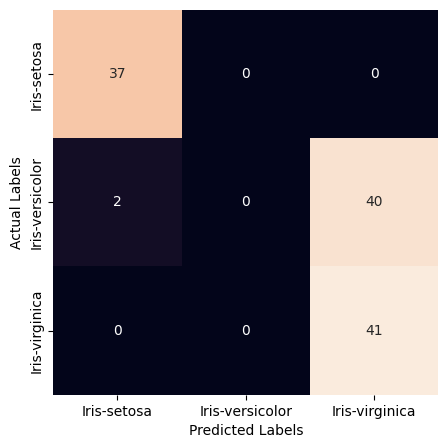

In [ ]:
nb = ComplementNB()
ad.custom_crossvalidation(X_train, y_train, nb)

# Neural Networks and Deep Learning

## Baseline NN: Simple Perceptron
To configure MLPClassifier as a simple perceptron, you need to set it up with a single layer of neurons and no hidden layers. In this case, the model behaves like a basic linear classifier, similar to the original Perceptron model:
1.	No Hidden Layers
2.	Activation Function is 'identity' which applies no non-linear transformation.
3.	Solver: 'sgd' (Stochastic Gradient Descent).


Mean accuracy: 61.67% +/-6.67%
Mean precision: 61.10% +/-14.33%
Mean recall: 63.03% +/-6.18%
Mean F1-score is 57.42% +/-7.57%
                 precision    recall  f1-score   support

    Iris-setosa       1.00      0.95      0.97        37
Iris-versicolor       0.40      0.10      0.15        42
 Iris-virginica       0.47      0.85      0.60        41

       accuracy                           0.62       120
      macro avg       0.62      0.63      0.58       120
   weighted avg       0.61      0.62      0.56       120



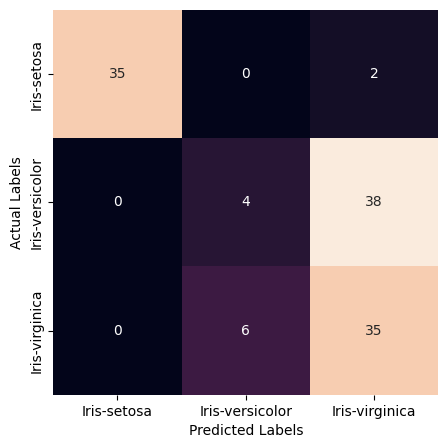

In [ ]:
perc_nn = MLPClassifier(hidden_layer_sizes=(), activation='identity',
                        solver='sgd', random_state=43)
ad.custom_crossvalidation(X_train, y_train, perc_nn)

In [ ]:
perc_nn.fit(X, y)
perc_nn.coefs_, perc_nn.intercepts_

([array([[-0.86851626,  0.06918871, -0.39032872],
         [-0.53666839, -0.37483923,  0.7760901 ],
         [ 0.15708242, -0.06164527, -0.58377708],
         [ 0.38328247, -0.25711749,  0.67142043]])],
 [array([-0.47578575, -0.83801088,  0.71748462])])

In [ ]:
# function to get the weights and biases in tabular format
def weights_to_matrix(clf):
    weights = clf.coefs_[0]
    df = pd.DataFrame(weights, columns=clf.classes_, index=clf.feature_names_in_)
    df.loc['bias'] = clf.intercepts_[0]
    return df

# call the above function
weights_to_matrix(perc_nn)

,Iris-setosa,Iris-versicolor,Iris-virginica
petallength,-0.868516,0.069189,-0.390329
petalwidth,-0.536668,-0.374839,0.776090
sepallength,0.157082,-0.061645,-0.583777
sepalwidth,0.383282,-0.257117,0.671420
bias,-0.475786,-0.838011,0.717485


## More Complex Neural Networks
- create a NN with one hidden layer that has 10 hidden neurons

Mean accuracy: 84.17% +/-6.12%
Mean precision: 88.76% +/-4.17%
Mean recall: 84.81% +/-6.02%
Mean F1-score is 83.61% +/-7.40%
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        37
Iris-versicolor       0.96      0.57      0.72        42
 Iris-virginica       0.69      0.98      0.81        41

       accuracy                           0.84       120
      macro avg       0.88      0.85      0.84       120
   weighted avg       0.88      0.84      0.84       120



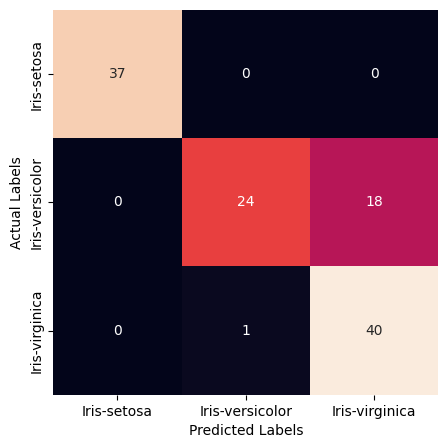

In [ ]:
nn = MLPClassifier(hidden_layer_sizes=(10), random_state=43)
ad.custom_crossvalidation(X_train, y_train, nn)

In [ ]:
params_nn = {
    'hidden_layer_sizes': [(50, 10), (100, 25)],
    'activation': ['logistic', 'relu'],
    'learning_rate_init': [0.0001, 0.001, 0.01, 1],
    'max_iter': [200],
    'momentum': [0.1, 0.3, 0.5, 0.7, 0.9],
    'epsilon': [1e-08, 1e-07, 1e-06, 1e-05, 1e-04, 1e-03, 1e-02, 1e-01]
}

## optimise for accuracy
grid_search_nn = GridSearchCV(MLPClassifier(random_state=43),
                              param_grid=params_nn, scoring='accuracy')
grid_search_nn.fit(X_train, y_train)
print(grid_search_nn.best_params_)
print(grid_search_nn.best_estimator_)
print(grid_search_nn.best_score_)

{'activation': 'logistic', 'epsilon': 1e-08, 'hidden_layer_sizes': (100, 25), 'learning_rate_init': 0.001, 'max_iter': 200, 'momentum': 0.1}
MLPClassifier(activation='logistic', hidden_layer_sizes=(100, 25), momentum=0.1,
              random_state=43)
0.975


### Apply optimal NN model to test data

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        13
Iris-versicolor       1.00      1.00      1.00         8
 Iris-virginica       1.00      1.00      1.00         9

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



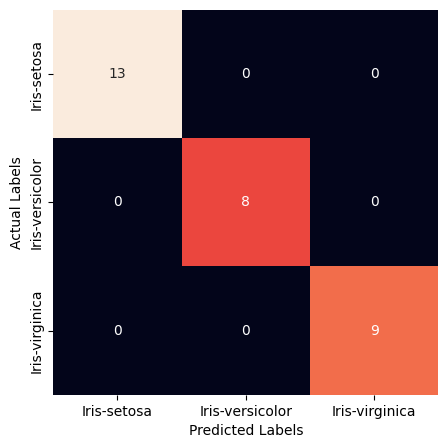

In [ ]:
y_pred = grid_search_nn.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))
ad.plot_confusion_matrix(y_test, y_pred)

## Using Tensorflow Library

### Binary Classification Example

In [ ]:
sonar = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Work 2025-2026/ADSA/sonar.csv', sep=';')
sonar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   attribute_1   208 non-null    float64
 1   attribute_2   208 non-null    float64
 2   attribute_3   208 non-null    float64
 3   attribute_4   208 non-null    float64
 4   attribute_5   208 non-null    float64
 5   attribute_6   208 non-null    float64
 6   attribute_7   208 non-null    float64
 7   attribute_8   208 non-null    float64
 8   attribute_9   208 non-null    float64
 9   attribute_10  208 non-null    float64
 10  attribute_11  208 non-null    float64
 11  attribute_12  208 non-null    float64
 12  attribute_13  208 non-null    float64
 13  attribute_14  208 non-null    float64
 14  attribute_15  208 non-null    float64
 15  attribute_16  208 non-null    float64
 16  attribute_17  208 non-null    float64
 17  attribute_18  208 non-null    float64
 18  attribute_19  208 non-null    

In [ ]:
sonar['class'].value_counts()

,count
class,
Mine,111
Rock,97


In [ ]:
X_sonar = sonar[sonar.columns.difference(['class'])]
y_enc = sonar['class'].map({'Mine': 0, 'Rock': 1})
X_train, X_test, y_train, y_test = train_test_split(X_sonar, y_enc, test_size=0.2, random_state=43)

We are going to use a sequential workflow which is created using the class Sequential, to which we can add any amount of layers. In our example:
1. the first layer is the input layer
2. then we can add 2 fully connected hidden layers using the Dense class (use the relu activation function)
3. the last one is the output layer with 1 neuron where sigmoid is applied since we have 2 classes.

Then we compile the model where we can specify the optimiser, and the loss function: binary_crossentropy for binary classification.

In [ ]:
seq_model = Sequential()
seq_model.add(Input(shape=(X_train.shape[1],)))
seq_model.add(Dense(5, activation='relu'))
seq_model.add(Dense(2, activation='relu'))
seq_model.add(Dense(1, activation='sigmoid'))
seq_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print(seq_model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 5)                   │             305 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │              12 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               3 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 320 (1.25 KB)

 Trainable params: 320 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# train the model using 50 epochs
seq_model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=2)

Epoch 1/50
6/6 - 2s - 275ms/step - accuracy: 0.5000 - loss: 0.6868
Epoch 2/50
6/6 - 0s - 16ms/step - accuracy: 0.5060 - loss: 0.6830
Epoch 3/50
6/6 - 0s - 9ms/step - accuracy: 0.5241 - loss: 0.6805
Epoch 4/50
6/6 - 0s - 8ms/step - accuracy: 0.5301 - loss: 0.6780
Epoch 5/50
6/6 - 0s - 9ms/step - accuracy: 0.5482 - loss: 0.6756
Epoch 6/50
6/6 - 0s - 9ms/step - accuracy: 0.5301 - loss: 0.6731
Epoch 7/50
6/6 - 0s - 11ms/step - accuracy: 0.5241 - loss: 0.6707
Epoch 8/50
6/6 - 0s - 10ms/step - accuracy: 0.5361 - loss: 0.6690
Epoch 9/50
6/6 - 0s - 9ms/step - accuracy: 0.5241 - loss: 0.6677
Epoch 10/50
6/6 - 0s - 10ms/step - accuracy: 0.5241 - loss: 0.6661
Epoch 11/50
6/6 - 0s - 9ms/step - accuracy: 0.5482 - loss: 0.6647
Epoch 12/50
6/6 - 0s - 10ms/step - accuracy: 0.5843 - loss: 0.6631
Epoch 13/50
6/6 - 0s - 10ms/step - accuracy: 0.5843 - loss: 0.6615
Epoch 14/50
6/6 - 0s - 24ms/step - accuracy: 0.5663 - loss: 0.6597
Epoch 15/50
6/6 - 0s - 24ms/step - accuracy: 0.5783 - loss: 0.6583
Epoch 16/

In [ ]:
# evaluate the model on the test portion
acc = seq_model.evaluate(X_test, y_test)
# accuracy and loss (loss needs to be compared to log of 2 in this case,
# because we have 2 classes, and this is 0.693)
acc

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7262 - loss: 0.5726  


[0.584761381149292, 0.7142857313156128]

### Multiclass Classification Example with built in validation on the training portion
- in the last layer we must apply the softmax function  
- the loss function needs to be categorical_crossentropy or sparse_categorical_crossentropy

In [ ]:
# separate the class label from regular attributes
y = iris['iris'].map({'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2})
X = iris[iris.columns.difference(['iris'])]
# split the dataset into 2 portions:
# one for training and validation, one for the final testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=43
)

In [ ]:
# use a sequential model to which we add several layers
seq_model = Sequential()
# this is the input layer
seq_model.add(Input(shape=(X_train.shape[1],)))
# the next 3 are fully connceted layers;
# 2 of them use the relu activation function
seq_model.add(Dense(7, activation='relu'))
seq_model.add(Dense(5, activation='relu'))
# the last uses the softmax activation function with 3 output neurons, one for each class
seq_model.add(Dense(3, activation='softmax'))
# compile the model
seq_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print(seq_model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 7)                   │              35 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 5)                   │              40 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 3)                   │              18 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 93 (372.00 B)

 Trainable params: 93 (372.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# train the model
seq_model.fit(X_train, y_train, epochs=50, validation_split=0.2)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.3490 - loss: 1.2974 - val_accuracy: 0.2917 - val_loss: 1.4009
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3607 - loss: 1.2587 - val_accuracy: 0.2917 - val_loss: 1.3523
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3177 - loss: 1.2432 - val_accuracy: 0.2917 - val_loss: 1.3071
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3841 - loss: 1.2159 - val_accuracy: 0.2917 - val_loss: 1.2703
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3646 - loss: 1.1528 - val_accuracy: 0.2917 - val_loss: 1.2534
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3138 - loss: 1.2066 - val_accuracy: 0.2917 - val_loss: 1.2425
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3685 - loss: 1.1118 - val_accuracy: 0.2917 - val_loss: 1.2321
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3919 - loss: 1.1055 - val_accuracy: 0.2917 - val_loss: 1.2211


In [ ]:
# evaluate the model on the test portion
acc = seq_model.evaluate(X_test, y_test)
acc

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7333 - loss: 0.9181


[0.9181316494941711, 0.7333333492279053]

## A Simple Convolutional network with keras tensorflow
- we will use the CIFAR dataset (https://www.cs.toronto.edu/%7Ekriz/cifar.html) which consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images.
- we will select only 2 types of images: horses and dogs

In [ ]:
# load the CIFAR data
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

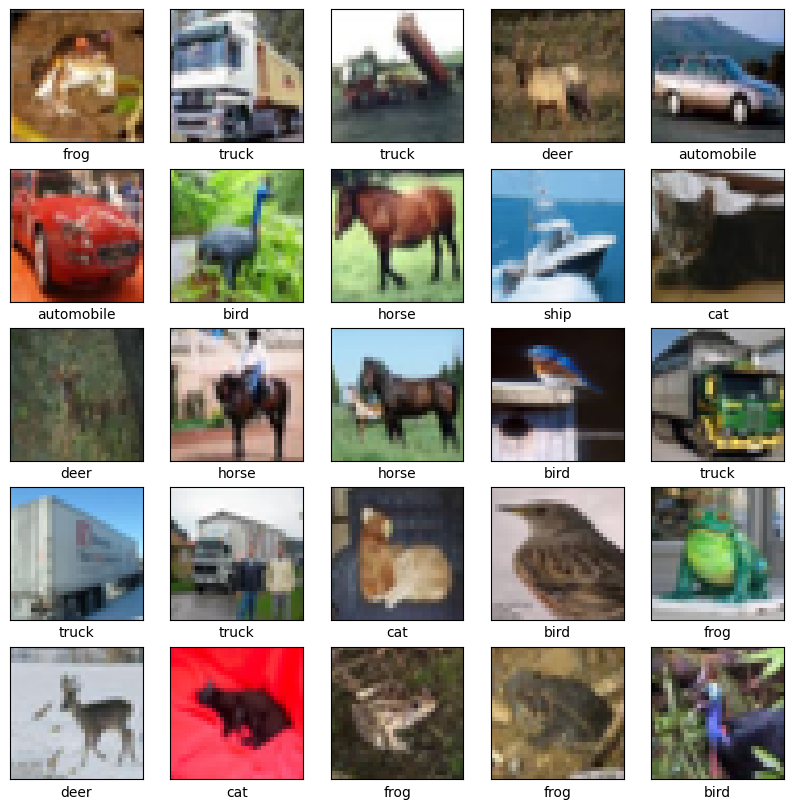

In [ ]:
# display the first 25 images from the dataset
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

In [ ]:
# indices for dogs and horses
indices = [5, 7]
# filter training data for dogs and horses
train_indices = np.isin(train_labels, indices).flatten()
train_images = train_images[train_indices]
train_labels = train_labels[train_indices]
# filter test data for dogs and horses
test_indices = np.isin(test_labels, indices).flatten()
test_images = test_images[test_indices]
test_labels = test_labels[test_indices]
# map labels of 5 to 0 and 7 to 1
train_labels = np.where(train_labels == 5, 0, 1)
test_labels = np.where(test_labels == 5, 0, 1)

In [ ]:
train_labels[:10]

array([[1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [0]])

In [ ]:
# create a sequential model
model = Sequential()
# add several convolutional and pooling(max) layers to form the convolutional base
# NOTE: a CNN convolutional layer takes tensors of shape
# (image_height, image_width, color_channels) for instance, (32, 32, 3)
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
# the flatten layer is used to convert 2d arrays/tensors to 1d
model.add(Flatten())
# the dense layers are fully connected layers
model.add(Dense(64, activation='relu'))
model.add(Dense(2))

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 4, 4, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │          65,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 122,050 (476.76 KB)

 Trainable params: 122,050 (476.76 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
# train the model ausing 10 epochs and store the results
early_stopping = EarlyStopping(monitor='val_loss', patience=3)
results = model.fit(train_images, train_labels, epochs=50,
                    validation_split=0.2, callbacks=[early_stopping])

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 45ms/step - accuracy: 0.4924 - loss: 0.8647 - val_accuracy: 0.5115 - val_loss: 0.6931
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.5049 - loss: 0.6931 - val_accuracy: 0.5115 - val_loss: 0.6931
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.4990 - loss: 0.6931 - val_accuracy: 0.5115 - val_loss: 0.6931
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.4928 - loss: 0.6931 - val_accuracy: 0.5115 - val_loss: 0.6931


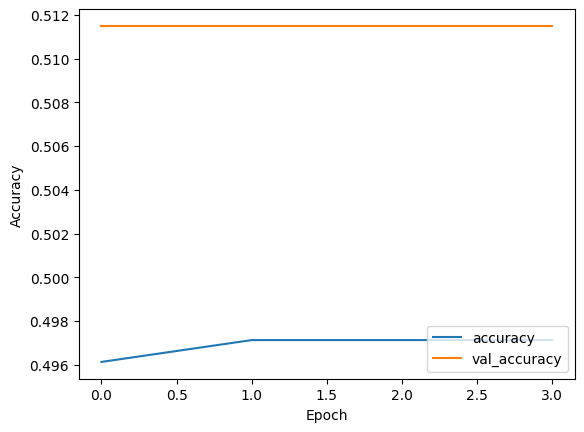

In [ ]:
# plot the results for both the training and validation portions
plt.plot(results.history['accuracy'], label='accuracy')
plt.plot(results.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
#plt.ylim([0.5, 1])
plt.legend(loc='lower right')

In [ ]:
# apply the model to the test images and get the loss and accuracy
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

63/63 - 1s - 19ms/step - accuracy: 0.5000 - loss: 0.6931
